# Final Comparison: EfficientNetB0 vs ResNet50 — All Experiments
Loads all 6 results CSVs and produces the complete comparison across both models and all 3 experiments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load all results ────────────────────────────────────
# Add all results CSVs as a single Kaggle dataset input
eff1 = pd.read_csv('/kaggle/input/notebooks/elaffa/01-efficientnetb0-exp1-frozen/exp1_results.csv')
eff2 = pd.read_csv('/kaggle/input/notebooks/elaffa/02-efficientnetb0-exp2-augmentation/exp2_results.csv')
eff3 = pd.read_csv('/kaggle/input/notebooks/elaffa/03-efficientnetb0-exp3-finetuning/exp3_results.csv')
res1 = pd.read_csv('/kaggle/input/notebooks/elaffa/05-resnet50-exp1-frozen/resnet_exp1_results.csv')
res2 = pd.read_csv('/kaggle/input/notebooks/elaffa/06-resnet50-exp2-augmentation/resnet_exp2_results.csv')
res3 = pd.read_csv('/kaggle/input/notebooks/elaffa/07-resnet50-exp3-finetuning/resnet_exp3_results.csv')

all_results = pd.concat([eff1, eff2, eff3, res1, res2, res3], ignore_index=True)
print(all_results[['model','experiment','test_acc','f1_weighted','precision','recall','test_loss']].to_string(index=False))

         model        experiment  test_acc  f1_weighted  precision  recall  test_loss
EfficientNetB0     Exp1 - Frozen    0.9085       0.9065     0.9124  0.9085     0.2712
EfficientNetB0 Exp2 - Frozen+Aug    0.8923       0.8928     0.9025  0.8923     0.3308
EfficientNetB0 Exp3 - Fine-Tuned    0.8668       0.8672     0.8794  0.8668     0.4241
      ResNet50     Exp1 - Frozen    0.8789       0.8774     0.8871  0.8789     0.4120
      ResNet50 Exp2 - Frozen+Aug    0.8735       0.8727     0.8776  0.8735     0.3628
      ResNet50 Exp3 - Fine-Tuned    0.8668       0.8659     0.8715  0.8668     0.3818


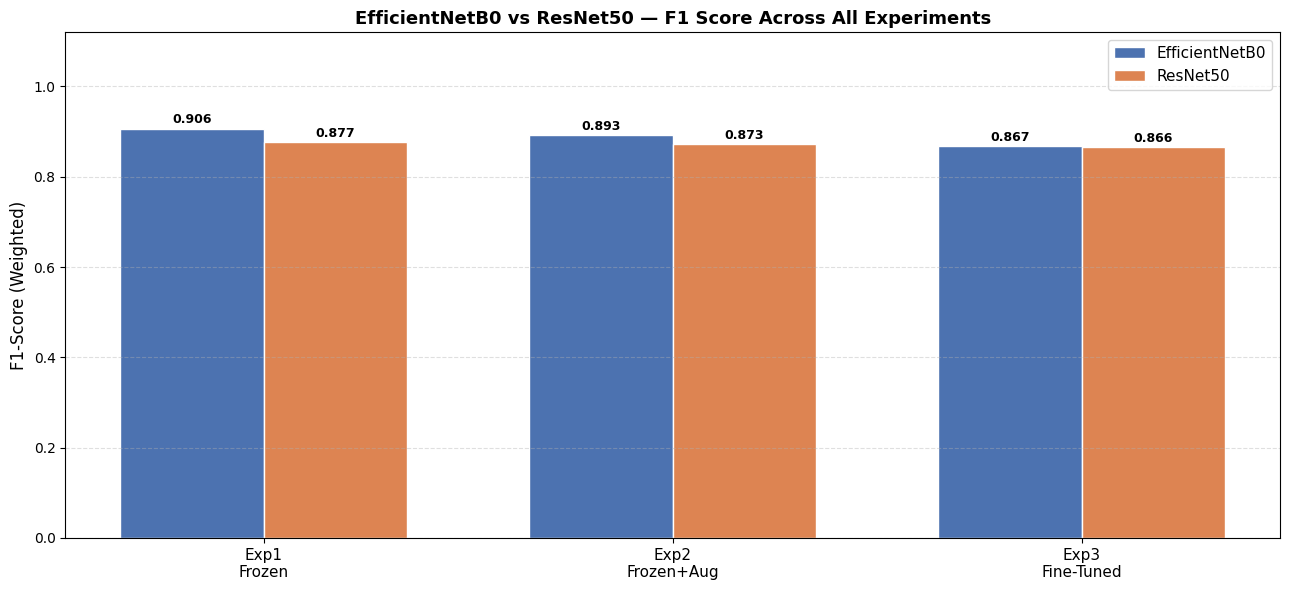

In [2]:
# ── F1-Weighted Comparison: All 6 Runs ──────────────────
fig, ax = plt.subplots(figsize=(13, 6))

eff_results = all_results[all_results['model'] == 'EfficientNetB0']
res_results = all_results[all_results['model'] == 'ResNet50']

x     = np.arange(3)
width = 0.35
exp_labels = ['Exp1\nFrozen', 'Exp2\nFrozen+Aug', 'Exp3\nFine-Tuned']

bars1 = ax.bar(x - width/2, eff_results['f1_weighted'].values, width,
               label='EfficientNetB0', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, res_results['f1_weighted'].values, width,
               label='ResNet50', color='#DD8452', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(exp_labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('F1-Score (Weighted)', fontsize=12)
ax.set_title('EfficientNetB0 vs ResNet50 — F1 Score Across All Experiments',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/final_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

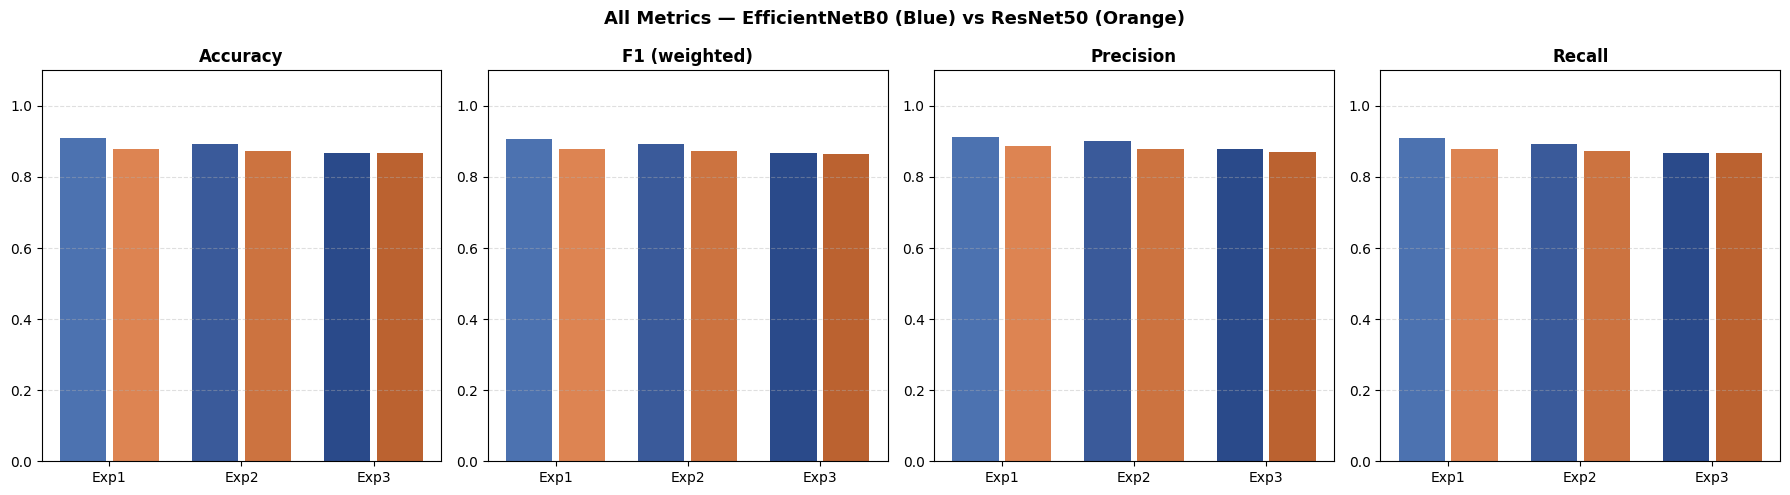

In [3]:
# ── All Metrics Side by Side ─────────────────────────────
metrics = ['test_acc', 'f1_weighted', 'precision', 'recall']
labels  = ['Accuracy', 'F1 (weighted)', 'Precision', 'Recall']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors_eff = ['#4C72B0', '#3a5a9a', '#2a4a8a']
colors_res = ['#DD8452', '#cc7340', '#bb6230']

for ax, metric, label in zip(axes, metrics, labels):
    for i, (_, row) in enumerate(eff_results.iterrows()):
        ax.bar(i - 0.2, row[metric], 0.35,
               color=colors_eff[i], label=f'EFF {row["experiment"]}' if i == 0 else '')
    for i, (_, row) in enumerate(res_results.iterrows()):
        ax.bar(i + 0.2, row[metric], 0.35,
               color=colors_res[i], label=f'RES {row["experiment"]}' if i == 0 else '')
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Exp1', 'Exp2', 'Exp3'])
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('All Metrics — EfficientNetB0 (Blue) vs ResNet50 (Orange)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/final_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ── Final Summary Table ──────────────────────────────────
print('='*75)
print('FINAL COMPARISON — EfficientNetB0 vs ResNet50')
print('='*75)
print(all_results[['model','experiment','test_acc','f1_weighted',
                   'precision','recall','test_loss']].to_string(index=False))
print('='*75)

best = all_results.loc[all_results['f1_weighted'].idxmax()]
print(f'\n🏆 BEST OVERALL MODEL')
print(f'   Model      : {best["model"]}')
print(f'   Experiment : {best["experiment"]}')
print(f'   Accuracy   : {best["test_acc"]:.4f}')
print(f'   F1         : {best["f1_weighted"]:.4f}')
print(f'   Precision  : {best["precision"]:.4f}')
print(f'   Recall     : {best["recall"]:.4f}')
print(f'   Loss       : {best["test_loss"]:.4f}')
print('='*75)

FINAL COMPARISON — EfficientNetB0 vs ResNet50
         model        experiment  test_acc  f1_weighted  precision  recall  test_loss
EfficientNetB0     Exp1 - Frozen    0.9085       0.9065     0.9124  0.9085     0.2712
EfficientNetB0 Exp2 - Frozen+Aug    0.8923       0.8928     0.9025  0.8923     0.3308
EfficientNetB0 Exp3 - Fine-Tuned    0.8668       0.8672     0.8794  0.8668     0.4241
      ResNet50     Exp1 - Frozen    0.8789       0.8774     0.8871  0.8789     0.4120
      ResNet50 Exp2 - Frozen+Aug    0.8735       0.8727     0.8776  0.8735     0.3628
      ResNet50 Exp3 - Fine-Tuned    0.8668       0.8659     0.8715  0.8668     0.3818

🏆 BEST OVERALL MODEL
   Model      : EfficientNetB0
   Experiment : Exp1 - Frozen
   Accuracy   : 0.9085
   F1         : 0.9065
   Precision  : 0.9124
   Recall     : 0.9085
   Loss       : 0.2712
